In [ ]:
# Projet: Estimation du traffic routier 

In [106]:
# Importation des modules et packages necessaires:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, MaxPool1D, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [107]:
# Impotration des données
data = pd.read_csv('D:\\DOCUMENTS\\PROJETS\\Estimation-du-traffic-routier---ATUT2025\\data\\traffic.csv')

# Exploration des données: La base contient le nombre de vehicule à 4 carreours toutes les heures
Notre dataset contient les variables suivantes:
- DateTime: la date de l'observation
- Junction: le numero du carrefour
- Vehicles: Le nombre de vehicules qui ont traversé le carrefour pendant l'heure d'observation

In [108]:
data.head(2)

,DateTime,Junction,Vehicles,ID
0,11/1/2015 0:00,1,15,20151101001
1,11/1/2015 1:00,1,13,20151101011


In [109]:
data.dtypes

DateTime      str
Junction    int64
Vehicles    int64
ID          int64
dtype: object

In [ ]:
# Conversion du type de la variable DateTime en datetime et suppression de la variable ID

In [ ]:
data["DateTime"] = pd.to_datetime(data["DateTime"])
data.drop("ID", axis=1, inplace=True)

data.dtypes

In [112]:
data.head(2)

,DateTime,Junction,Vehicles
0,2015-11-01 00:00:00,1,15
1,2015-11-01 01:00:00,1,13


In [113]:
data = data.rename(columns={'Junction': 'Jonction', 'Vehicles':'Vehicules', 'DateTime':'DateHeure'})
new_data = data.copy()

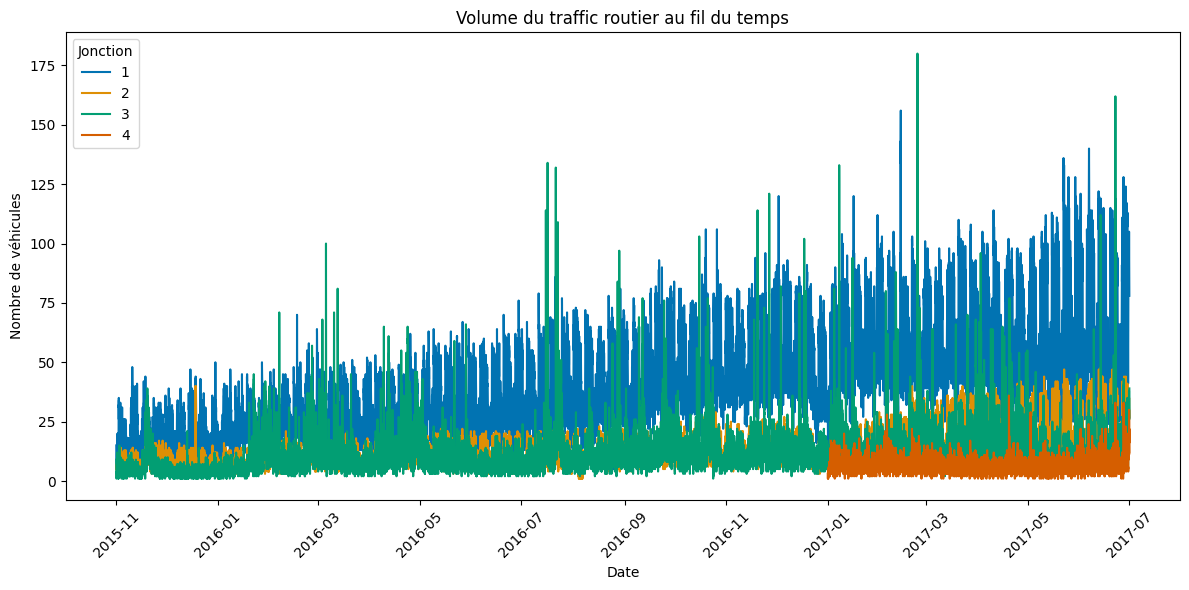

In [114]:
# Visualisation des données
def plot_traffic(data):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x= data['DateHeure'], y='Vehicules', data=data, hue='Jonction', palette='colorblind')
    plt.title('Volume du traffic routier au fil du temps')
    plt.xlabel('Date')
    plt.ylabel('Nombre de véhicules')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_traffic(new_data)

In [115]:
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DateHeure  48120 non-null  datetime64[us]
 1   Jonction   48120 non-null  int64         
 2   Vehicules  48120 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.1 MB


# Feature engineering: 
Ici je vais construire de nouvelles variables pour extraire des informations surtout à partir de la colonne date.

A partir de la visualisation précédente, on observe que:
- Le nombre de véhicule à la jonction 1 montre une tendence haussière
- Les données sur la jonctions 4, commence seulement à partir de janvier 2017

Donc pour avoir suffisament d'informations, on va devoir extraire les années, les mois, les jours et heures


In [116]:
new_data["Annee"] = pd.to_datetime(new_data["DateHeure"]).dt.year
new_data["Mois"] = pd.to_datetime(new_data["DateHeure"]).dt.month
new_data["Jour"] = pd.to_datetime(new_data["DateHeure"]).dt.day
new_data["Heure"] = pd.to_datetime(new_data["DateHeure"]).dt.hour

new_data.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1


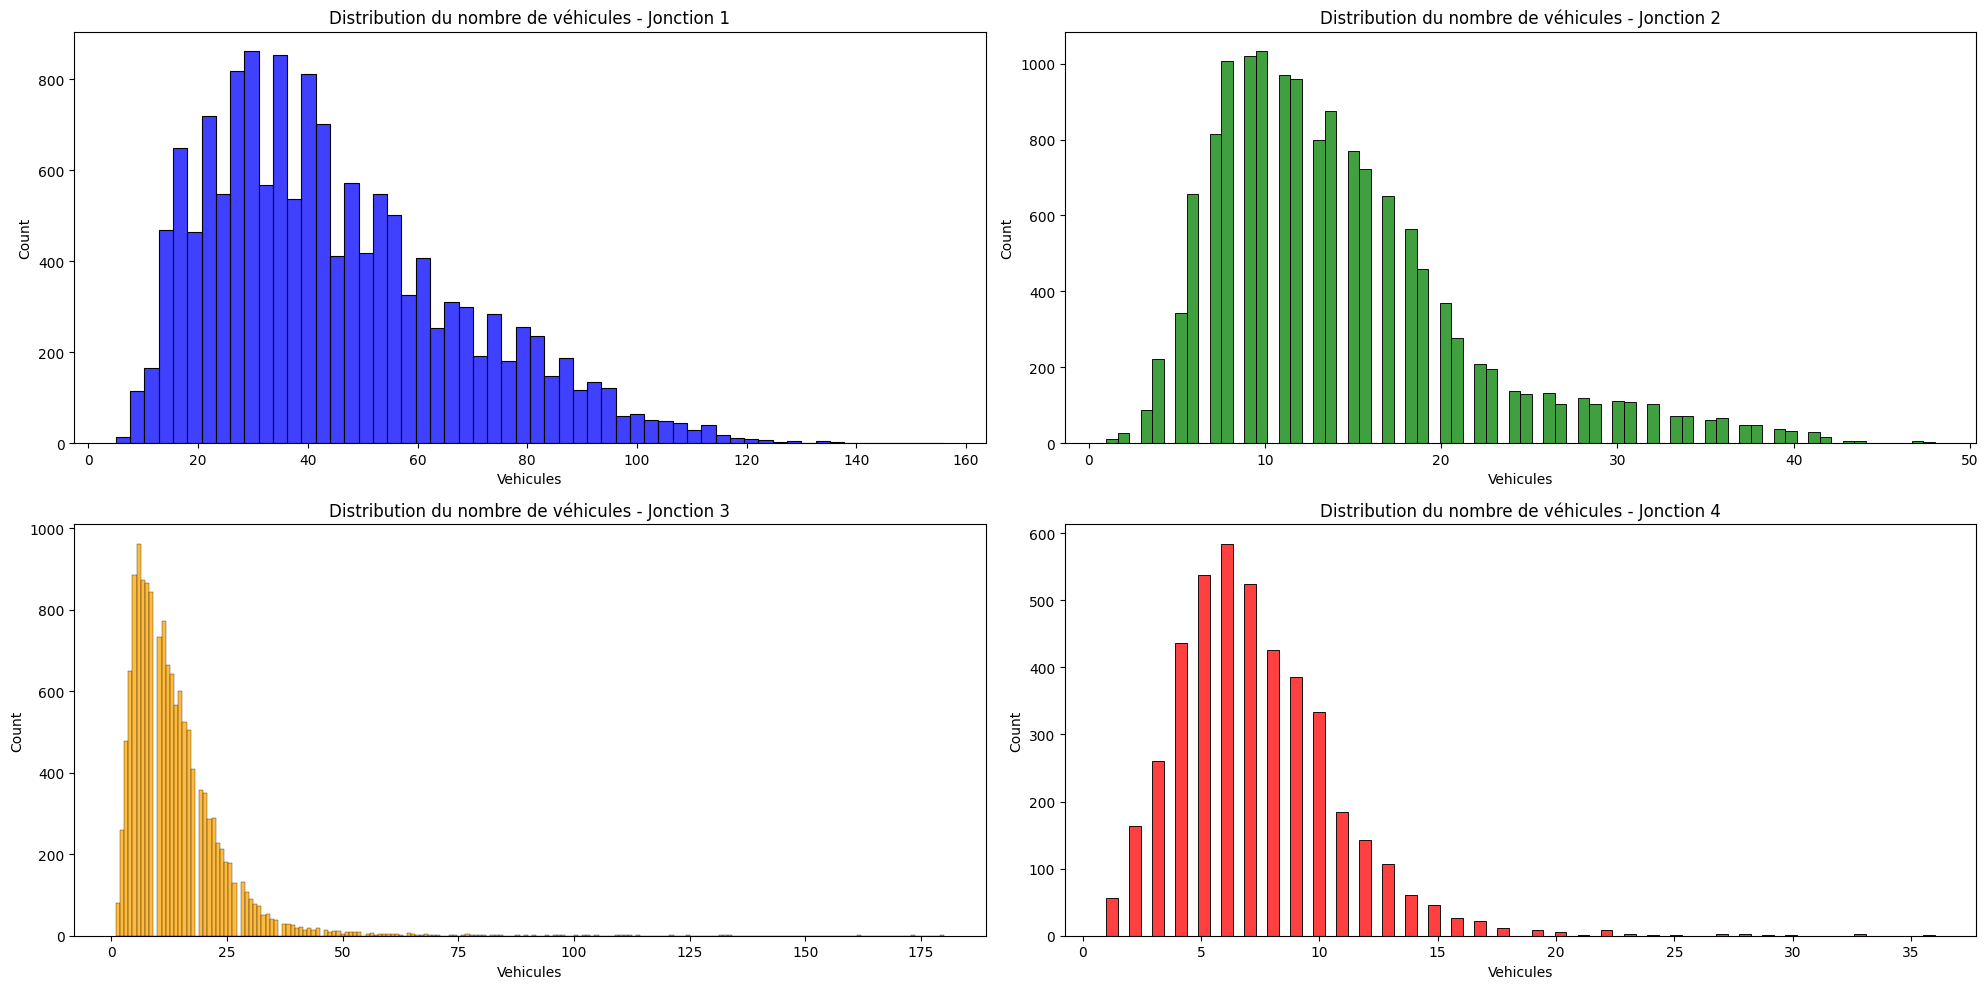

In [117]:
# Verifions la distribution du nombre de vehicules par jonctions
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0, 0].plot()
sns.histplot( data=new_data[new_data['Jonction'] == 1]["Vehicules"], ax=ax[0, 0], color='blue')
sns.histplot( data=new_data[new_data['Jonction'] == 2]["Vehicules"], ax=ax[0, 1], color='green')
sns.histplot( data=new_data[new_data['Jonction'] == 3]["Vehicules"], ax=ax[1, 0], color='orange')
sns.histplot( data=new_data[new_data['Jonction'] == 4]["Vehicules"], ax=ax[1, 1], color='red')
ax[0, 0].set_title('Distribution du nombre de véhicules - Jonction 1')
ax[0, 1].set_title('Distribution du nombre de véhicules - Jonction 2')
ax[1, 0].set_title('Distribution du nombre de véhicules - Jonction 3')
ax[1, 1].set_title('Distribution du nombre de véhicules - Jonction 4')
plt.tight_layout()  
plt.show()

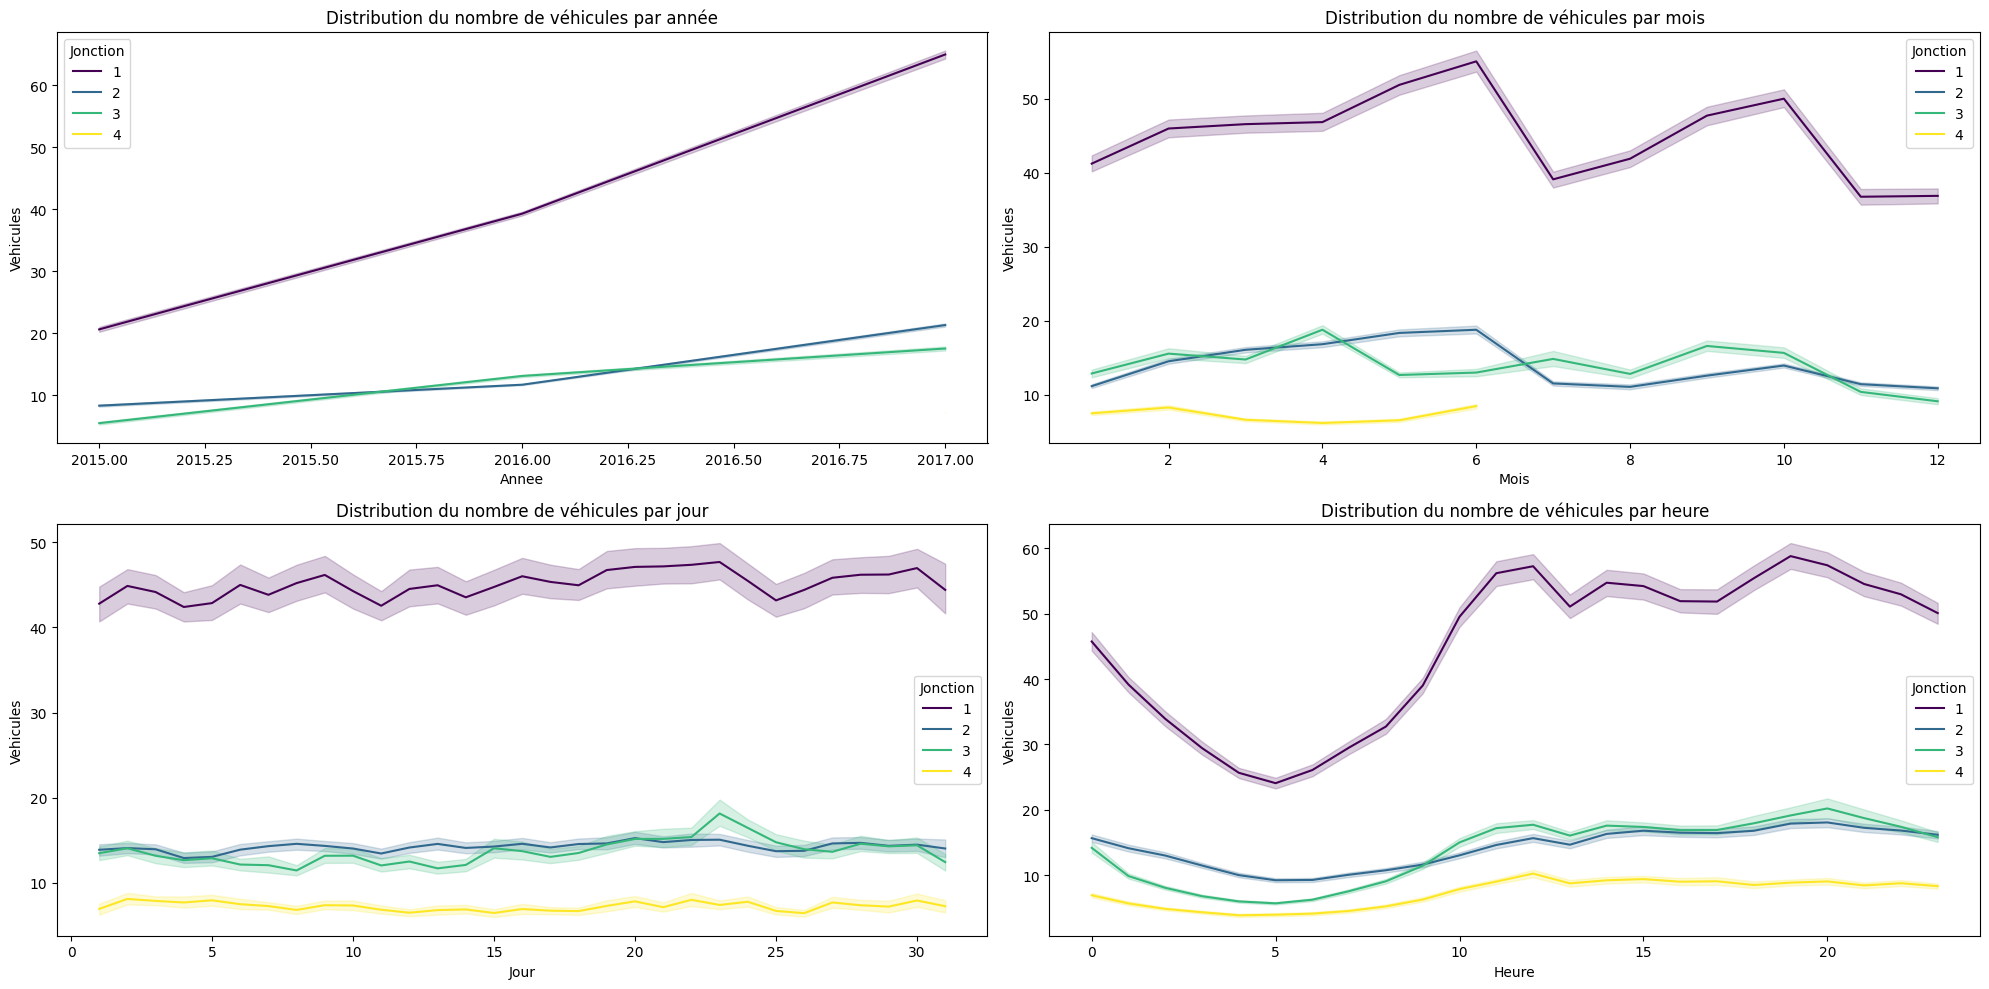

In [118]:
# Examinons l'évolution du nombre de véhicules en fonctions de nos nouvelles variables
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
sns.lineplot(data=new_data, x='Annee', y='Vehicules', ax=ax[0, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Mois', y='Vehicules', ax=ax[0, 1], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Jour', y='Vehicules', ax=ax[1, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Heure', y='Vehicules', ax=ax[1, 1], hue = "Jonction", palette='viridis')
ax[0, 0].set_title('Distribution du nombre de véhicules par année')
ax[0, 1].set_title('Distribution du nombre de véhicules par mois')
ax[1, 0].set_title('Distribution du nombre de véhicules par jour')
ax[1, 1].set_title('Distribution du nombre de véhicules par heure')
plt.tight_layout()  
plt.show()

# On observe sur la figure precedente que:
- Le nombre de véhicule présente une tendence haussière par anné pour toutes les jonctions à l'exception de la jonction 4 pour laquelle nous n'avons les données qu'à partir de 2017
- GLobalement, le nombre de véhicule dans ces jonctions augmente pendant le jour et diminue la nuit

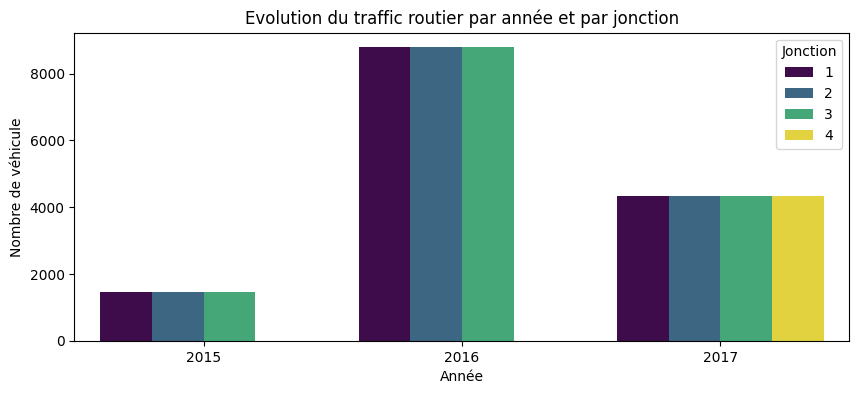

In [119]:
# Analysons l'évolution de ce traffic par année
plt.figure(figsize=(10, 4))
sns.countplot(data = new_data, x = new_data["Annee"], hue = "Jonction", palette="viridis")
plt.title("Evolution du traffic routier par année et par jonction")
plt.xlabel("Année")
plt.ylabel("Nombre de véhicule")
plt.show()

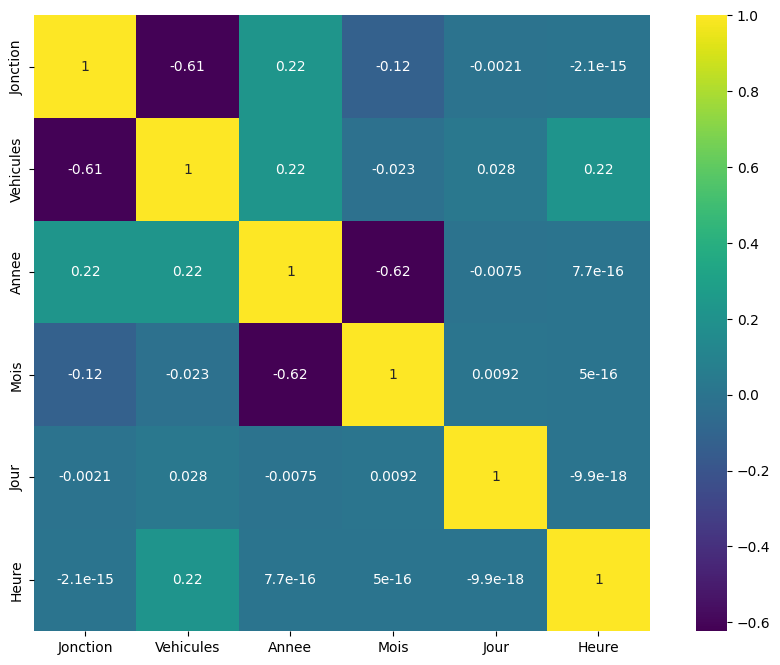

In [120]:
# Augmentation flagrante du traffic sur toutes les jonctions de 2015 à 2016

# Analyse de la correlation entre nos variables

traffic = new_data.copy()

correlations = traffic.drop("DateHeure", axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, cmap = "viridis", annot=True, square=True)
plt.show()

In [121]:
### Transformations de nos données pour les rendre plus adaptées à l'apprentissage automatique
# parce qu'il va falloire adapter les modeles pour chaque jonction

# Donc nous allons premierement prendre le cas de la premiere jonction pour developper le modele et comme 
# c'est la meme procedure ca ne sea pas complique de le afire pour les autres jonctions

type_jonction = 1

traffic_ = traffic[traffic["Jonction"] == type_jonction]
traffic_.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1


<Axes: xlabel='Jour', ylabel='Vehicules'>

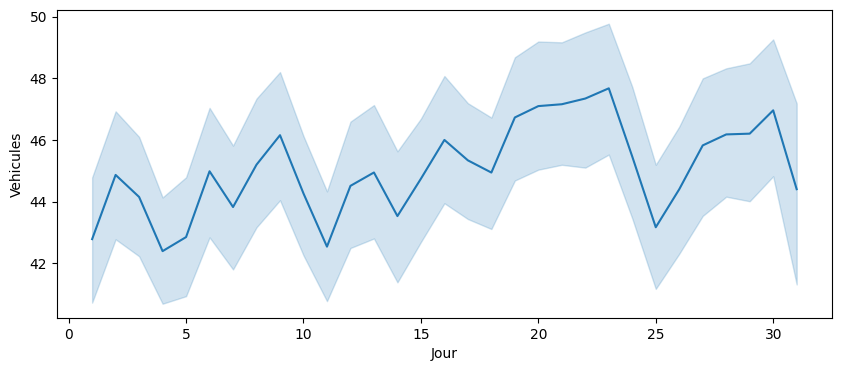

In [122]:
plt.figure(figsize=(10, 4))
sns.lineplot(x="Jour", y="Vehicules", data=traffic_)

In [ ]:
# Normalisation des donnees avec MinMaxScaler et comme il ya de la saisonnalite on va faire la differenciation
#  Pour la jonction 1, la saisonnalite est d'une semaine, donc on va faire la differenciation avec un lag de 7 jours

In [123]:
def Normalisation(df, col):
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])
    return df, scaler

def Difference(df,col, interval):
    diff = []
    for i in range(interval, len(df)):
        value = df[col][i] - df[col][i - interval]
        diff.append(value)
    return diff

In [124]:
traffic_current, scaler = Normalisation(traffic_, "Vehicules")
traffic_current.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,-1.306219,2015,11,1,0
1,2015-11-01 01:00:00,1,-1.393147,2015,11,1,1


In [125]:
traffic_norm = traffic_current["Vehicules"].to_frame()

<Figure size 800x400 with 0 Axes>

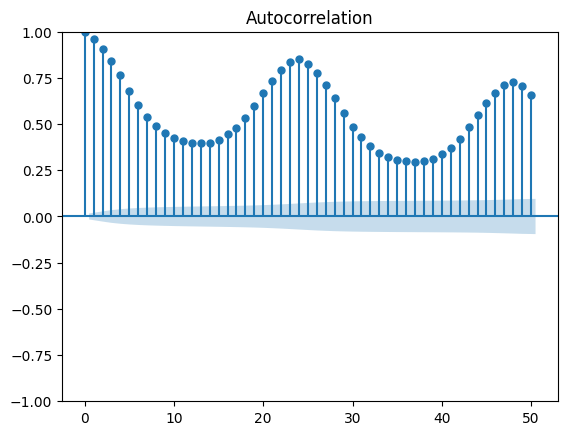

In [126]:
# Analyse des autocorrelations pour determiner les intervalles de differenciation: 
# Seasonalite (Une semaine (7 jours)))

plt.figure(figsize=(8, 4))
plot_acf(traffic_current["Vehicules"],lags=50)
plt.show()

In [127]:
Vehicules_diff = Difference(traffic_current, "Vehicules", interval= (24*7))

interval=24*7

traffic_norm = traffic_norm[interval:]

traffic_norm["Vehicules_diff"] = Vehicules_diff

traffic_traffic = traffic_norm["Vehicules_diff"].dropna()

traffic_traffic = traffic_traffic.to_frame()

traffic_traffic.head(2)

,Vehicules_diff
168,-0.086928
169,0.130392


In [128]:
traffic_traffic.shape

(14424, 1)

In [ ]:
# Etant donnée que nous somme en face des series temporelles, 
# il est important de faire le test de stationnarité des series

In [130]:
def test_stationnarite(df):
    test = adfuller(df.dropna())
    print(f"ADF Statistic: {test[0]}")
    print(f"p-value: {test[1]}")
    print("Critical Values:")
    for key, value in test[4].items():
        print('\t%s: %.3f' % (key, value))
    if test[0] > test[4]["1%"]:
        print("Les series temporelles ne sont pas stationnaires")
    else:
        print("Les series temporelles sont stationnaires") 

test_stationnarite(traffic_traffic["Vehicules_diff"])

ADF Statistic: -15.265303390415374
p-value: 4.798539876397681e-28
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Les series temporelles sont stationnaires


In [ ]:
# Les séries étant désormais stationnaires, nous préparons les données pour la phase de modélisation.

# Nous allons diviser les données en ensembles d'entraînement et de test, 
# en utilisant les 80% premiers points pour l'entraînement et les 20% restants pour le test.

In [131]:
def Split_data(df):
    training_size = int(len(df)*0.80)
    data_len = len(df)
    train, test = df[0:training_size],df[training_size:data_len] 
    train, test = train.values.reshape(-1, 1), test.values.reshape(-1, 1)
    return train, test
# Nous allons maintenant definir les features et les cibles pour l'apprentissage automatique tout en 
# respectant la nature temporelle de nos données donc il va falloire utiliser les retards

def Def_Features_Target(df):
    end_len = len(df)
    X = []
    y = []
    steps = 32
    for i in range(steps, end_len):
        X.append(df[i - steps:i, 0])
        y.append(df[i, 0])
    X, y = np.array(X), np.array(y)
    return X, y

# Regler les problemes de dimensions pour les modeles d'apprentissage automatique
def Correction_dimensions(train, test):
    train = np.reshape(train, (train.shape[0], train.shape[1], 1))
    test = np.reshape(test, (test.shape[0], test.shape[1], 1))
    return train, test

In [132]:
traffic_train, traffic_test = Split_data(traffic_traffic)
X_train, y_train = Def_Features_Target(traffic_train)
X_test, y_test = Def_Features_Target(traffic_test)
X_train, X_test = Correction_dimensions(X_train, X_test)

In [133]:
# NOus definions en meme temps les fonctions d'evaluation de nos modeles d'apprentissage automatique
def Evaluation_metrics(y_true, y_pred):
    metrics = {}
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    metrics["mse"] = mse
    metrics["mae"] =mae
    metrics["rmse"] = rmse
    return pd.DataFrame([metrics])

def predictions_plot(y_true, y_pred):
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Valeurs réelles", color='blue')
    plt.plot(y_pred, label="Valeurs prédites", color='red')
    plt.title("Comparaison entre les valeurs réelles et prédites")
    plt.xlabel("Index")
    plt.ylabel("Nombre de véhicules")
    plt.legend()
    plt.show()

In [ ]:
########## Comme nous somme en face des sequences, on va utiliser ici 
# LSTM et GRU pour la modelisation de nos données.

In [134]:
expo_decay = ExponentialDecay(initial_learning_rate=0.01, decay_steps=10000, decay_rate=0.9)

In [135]:
X_train.shape

(11507, 32, 1)

In [136]:
y_train.shape

(11507,)

In [36]:
def MY_LSTM_MODEL(X_train, y_train, X_test, y_test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    model = Sequential()
    model.add(LSTM(units = 200, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units = 300, activation='tanh', input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(Dense(units = 1))
    
    model.compile(optimizer=SGD(learning_rate=expo_decay, momentum=0.90), loss='mean_squared_error' )
    model.fit(X_train,y_train, validation_data=(X_test, y_test), epochs=100, batch_size=120, callbacks=[early_stopping])
    y_pred = model.predict(X_test)
    return y_pred, model



In [37]:
# Appel de notre modele LSTM pour la jonction 1
y_pred, my_lstm = MY_LSTM_MODEL(X_train, y_train, X_test, y_test)

d:\DOCUMENTS\PROJETS\Estimation-du-traffic-routier---ATUT2025\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - loss: 0.0937 - val_loss: 0.1141
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - loss: 0.0832 - val_loss: 0.1068
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - loss: 0.0807 - val_loss: 0.1061
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - loss: 0.0794 - val_loss: 0.1050
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.0781 - val_loss: 0.1041
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.0776 - val_loss: 0.1044
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - loss: 0.0768 - val_loss: 0.1035
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - loss: 0.0761 - val_loss: 0.1026
Epoch 9/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - loss: 0.0758 - val_loss: 0.1029
Epoch 10/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - loss: 0.0752 - val_loss: 0.1036
Epoch 11/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - loss: 0.0753 - val_loss: 0.1034
Epoch 12/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step

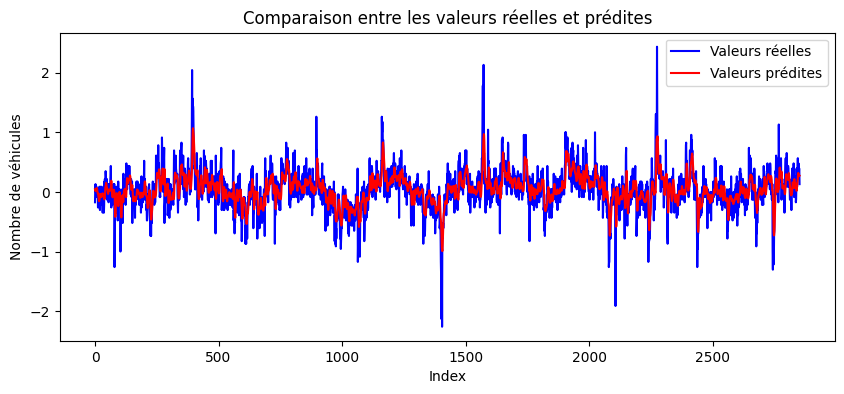

In [40]:
predictions_plot(y_test, y_pred)

In [137]:
metrics = Evaluation_metrics(y_test, y_pred)
print(metrics)

       mse       mae      rmse
0  0.06371  0.181657  0.252409


In [138]:
my_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 200)        │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32, 100)        │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 300)            │       481,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,603 (7.05 MB)

 Trainable params: 924,301 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 924,302 (3.53 MB)

In [ ]:
############ Definition d'une fonction qui va nous permettre de ramener les prediction a l'etat initial

In [139]:
X_test.shape[0]

2853

In [140]:
X_test.shape[0]

2853

In [173]:
def recover_predictions(model_pred, model_name):
    recover = traffic_norm[-(X_test.shape[0] + 1):-1]
    recover["Predictions"] = model_pred
    transform_reversed = recover.Vehicules + recover.Predictions
    transform_data = transform_reversed.to_frame()
    transform_data.columns = ["Pred_normed"]
    final_pred = scaler.inverse_transform(transform_data.values)
    transform_data["Prediction_final"] = final_pred
    donnee = traffic[traffic["Jonction"] == type_jonction]
    
    fig, ax = plt.subplots(2, 1, figsize=(15, 10))
    ax[0].plot()
    ax[0].plot(traffic_["DateHeure"][-(X_test.shape[0] +1 ):-1], transform_data["Prediction_final"], color='blue', lw =2)
    ax[1].plot(traffic_["DateHeure"][-(X_test.shape[0] +1):-1], donnee["Vehicules"][-(X_test.shape[0] +1):-1], color='red', lw=2)
    ax[0].set_title('Valeurs prédites par le modèle ' + str(model_name), fontsize=18)
    ax[0].set_xlabel("Date", fontsize=12)
    ax[0].set_ylabel("Nombre de véhicules", fontsize=12)
    ax[0].legend()
    ax[1].set_xlabel("Date", fontsize=12)
    ax[1].set_ylabel("Nombre de véhicules", fontsize=12)
    ax[1].set_title('Valeurs réelles', fontsize=18)
    ax[1].legend()
    plt.tight_layout()  
    plt.savefig("Valeurs prédites par le modèle " + str(model_name) + ".png")
    plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7292\4178095038.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7292\4178095038.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


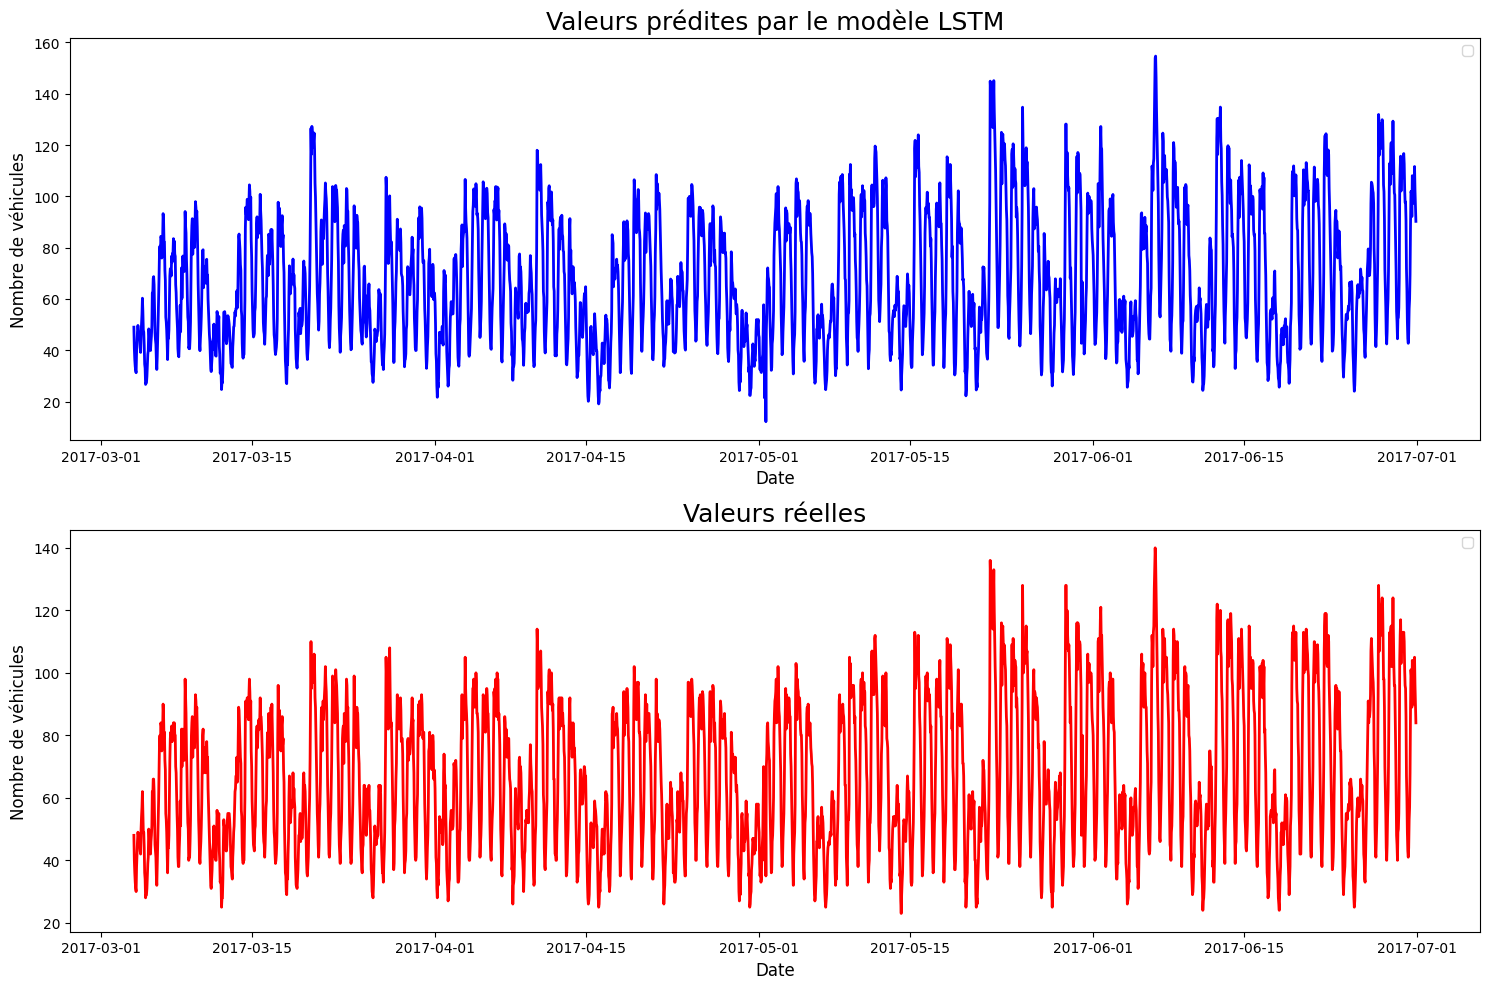

In [174]:
recover_predictions(y_pred, "LSTM")

In [184]:
# Nous allons creer une fonction qui va nous permettre de visualiser l'evolution de la fonction de perte de notre modele LSTM
def plot_loss_function(model, model_name):
    plt.plot(model.history.history['loss'], label='Training Loss', lw=2)
    plt.plot(model.history.history['val_loss'], label='Validation Loss', lw=2)
    plt.title('Evolution de la fonction de perte du modèle ' + str(model_name), fontsize=14)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.tight_layout()  
    plt.savefig("Evolution de la fonction de perte du modèle " + str(model_name) + ".png")
    plt.show()

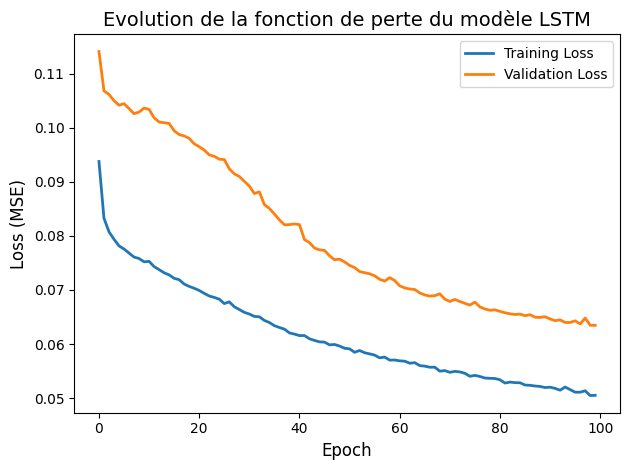

In [185]:
plot_loss_function(my_lstm, "LSTM")

In [ ]:
# Modelisation avec le modele GRU

In [192]:
from pyexpat import model


def MY_GRU_MODEL(X_train, y_train, X_test, y_test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    model_gru = Sequential()
    model_gru.add(GRU(units = 200, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(GRU(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(GRU(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model_gru.add(GRU(units = 100, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(GRU(units = 300, activation='tanh', input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(Dense(units = 1))
    
    model_gru.compile(optimizer=SGD(learning_rate=expo_decay, momentum=0.90), loss='mean_squared_error' )
    model_gru.fit(X_train,y_train, validation_data=(X_test, y_test), epochs=40, batch_size=120, callbacks=[early_stopping])
    gru_pred = model_gru.predict(X_test)
    return gru_pred, model_gru



In [193]:
# Appel de notre modele GRU pour la jonction 1
gru_pred, my_gru = MY_GRU_MODEL(X_train, y_train, X_test, y_test)

d:\DOCUMENTS\PROJETS\Estimation-du-traffic-routier---ATUT2025\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - loss: 0.0749 - val_loss: 0.0909
Epoch 2/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - loss: 0.0643 - val_loss: 0.0857
Epoch 3/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - loss: 0.0631 - val_loss: 0.0836
Epoch 4/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - loss: 0.0619 - val_loss: 0.0807
Epoch 5/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - loss: 0.0598 - val_loss: 0.0792
Epoch 6/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - loss: 0.0587 - val_loss: 0.0775
Epoch 7/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - loss: 0.0577 - val_loss: 0.0752
Epoch 8/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - loss: 0.0566 - val_loss: 0.0733
Epoch 9/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - loss: 0.0559 - val_loss: 0.0713
Epoch 10/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - loss: 0.0553 - val_loss: 0.0699
Epoch 11/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - loss: 0.0545 - val_loss: 0.0704
Epoch 12/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - loss: 0.0

In [194]:
metrics_gru = Evaluation_metrics(y_test, gru_pred)
print(metrics_gru)

        mse       mae      rmse
0  0.059617  0.176281  0.244166


In [195]:
my_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 32, 200)        │       121,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 32, 100)        │        90,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32, 100)        │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 32, 100)        │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 300)            │       361,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,391,403 (5.31 MB)

 Trainable params: 695,701 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 695,702 (2.65 MB)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7292\4178095038.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7292\4178095038.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


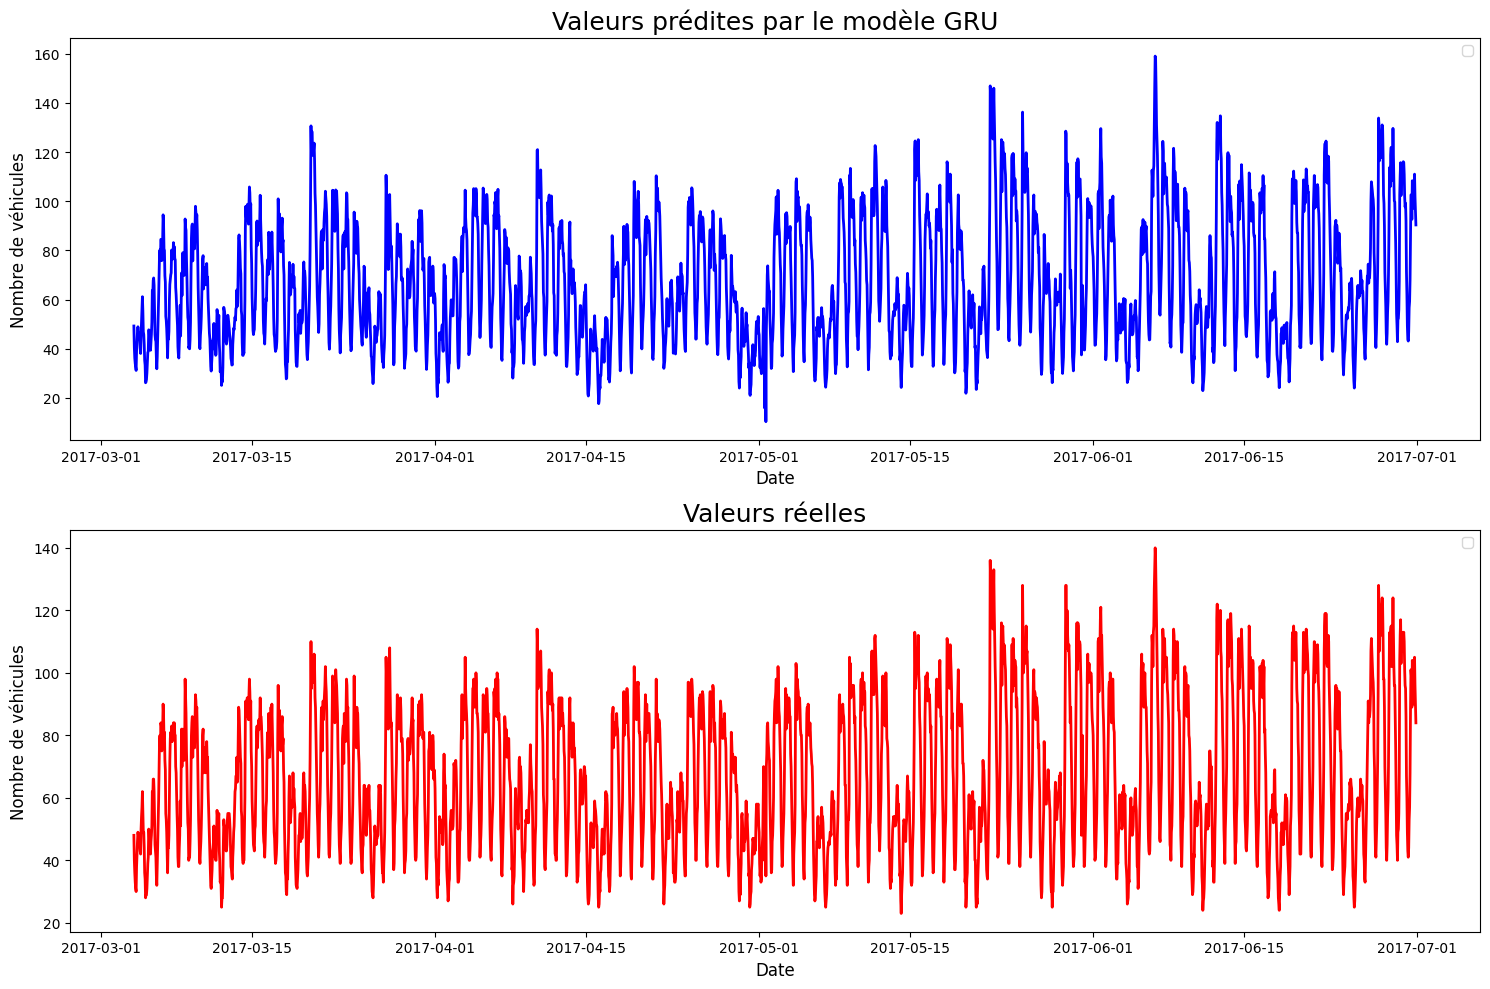

In [196]:
recover_predictions(gru_pred, "GRU")

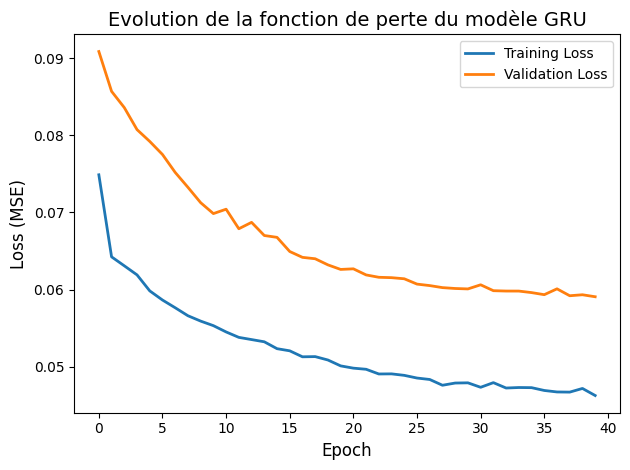

In [197]:
plot_loss_function(my_gru, "GRU")